**Prepared by**: Yash Yadav


In [45]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

In [46]:
from pathlib import Path
DATA_DIR=Path("D:\MachineLearningIET\data\raw")
DATA_DIR.exists()

<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Yash\AppData\Local\Temp\ipykernel_27312\3115697068.py:2: SyntaxWarning: invalid escape sequence '\M'
  DATA_DIR=Path("D:\MachineLearningIET\data\raw")


False

In [47]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
geolocation = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
category_translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

In [48]:
tables = {
"customers": customers,
"geolocation": geolocation,
"order_items": order_items,
"payments": payments,
"reviews": reviews,
"orders": orders,
"products": products,
"sellers": sellers,
"category_translation": category_translation}

In [49]:
for name, df in tables.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

customers: 99441 rows, 5 columns
geolocation: 1000163 rows, 5 columns
order_items: 112650 rows, 7 columns
payments: 103886 rows, 5 columns
reviews: 99224 rows, 7 columns
orders: 99441 rows, 8 columns
products: 32951 rows, 9 columns
sellers: 3095 rows, 4 columns
category_translation: 71 rows, 2 columns


In [50]:

customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [51]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [52]:
for name, df in tables.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

customers: 99441 rows, 5 columns
geolocation: 1000163 rows, 5 columns
order_items: 112650 rows, 7 columns
payments: 103886 rows, 5 columns
reviews: 99224 rows, 7 columns
orders: 99441 rows, 8 columns
products: 32951 rows, 9 columns
sellers: 3095 rows, 4 columns
category_translation: 71 rows, 2 columns


In [53]:

customers.info()


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [54]:
for name, df in tables.items():
    print("\n" + "=" * 80)
    print(name.upper())
    print("=" * 80)
    print(df.info())


CUSTOMERS
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None

GEOLOCATION
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str 

In [55]:
def summarize_table(name, df):
     return {
         "table_name": name,
         "rows": df.shape[0],
         "columns": df.shape[1],
         "missing_values": df.isnull().sum().sum(),
         "duplicate_rows": df.duplicated().sum()
         }
summary= pd. DataFrame([summarize_table(name, df) for name, df in tables.items()])

In [56]:
summary

,table_name,rows,columns,missing_values,duplicate_rows
0,customers,99441,5,0,0
1,geolocation,1000163,5,0,261831
2,order_items,112650,7,0,0
3,payments,103886,5,0,0
4,reviews,99224,7,145903,0
5,orders,99441,8,4908,0
6,products,32951,9,2448,0
7,sellers,3095,4,0,0
8,category_translation,71,2,0,0


In [57]:
summary.to_csv("D:/MachineLearningIET/notebooks/reports/lab01_dataset_summary.csv",index=False)

In [58]:
def missing_value_summary(df):
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100

    result = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percent": missing_percent
    })

    return result[result["missing_count"] > 0].sort_values(
        by="missing_percent",
        ascending=False
    )

missing_value_summary(orders)

,missing_count,missing_percent
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899


In [59]:
for name, df in tables.items():
    print("\n" + "=" * 80)
    print(f"Missing Values in {name}")
    print("=" * 80)
    display(missing_value_summary(df))


Missing Values in customers


,missing_count,missing_percent



Missing Values in geolocation


,missing_count,missing_percent



Missing Values in order_items


...

,missing_count,missing_percent
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070



Missing Values in sellers


,missing_count,missing_percent



Missing Values in category_translation


,missing_count,missing_percent


In [60]:

for name, df in tables.items():
     duplicate_count = df.duplicated().sum()
     print(f"{name}: {duplicate_count} duplicate rows")


customers: 0 duplicate rows
geolocation: 261831 duplicate rows
order_items: 0 duplicate rows
payments: 0 duplicate rows
reviews: 0 duplicate rows
orders: 0 duplicate rows
products: 0 duplicate rows
sellers: 0 duplicate rows
category_translation: 0 duplicate rows


In [61]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

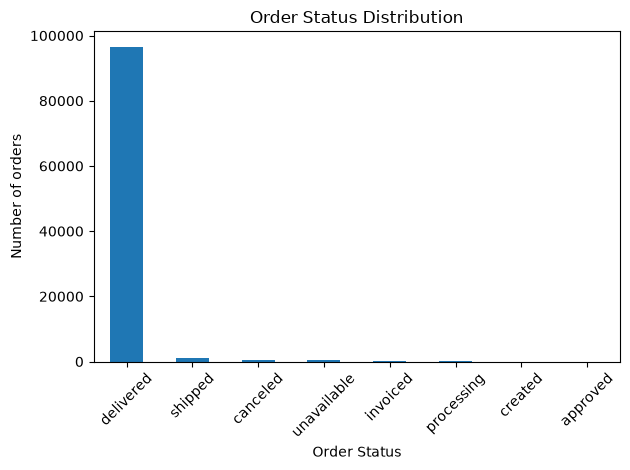

In [62]:
import matplotlib.pyplot as plt
orders["order_status"].value_counts().plot(kind="bar")
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/order_status_distri.png")
plt.show()

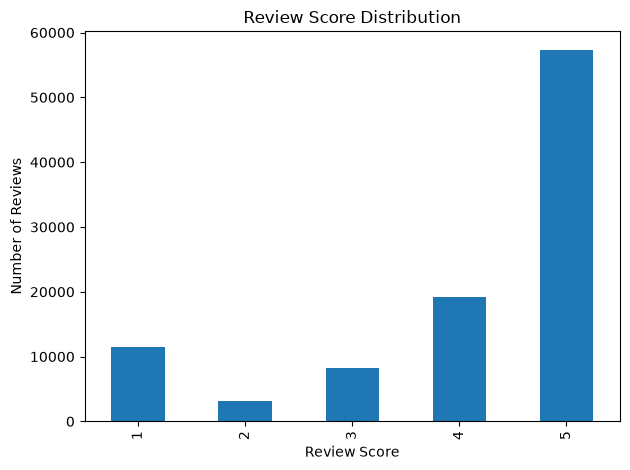

In [63]:
reviews["review_score"].value_counts().sort_index().plot(kind="bar")
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("../figures/review.png")
plt.show()

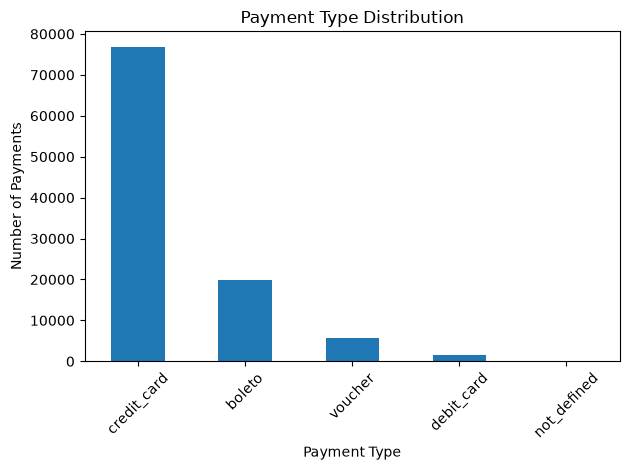

In [64]:
payments["payment_type"].value_counts().plot(kind="bar")
plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/payment.png")
plt.show()

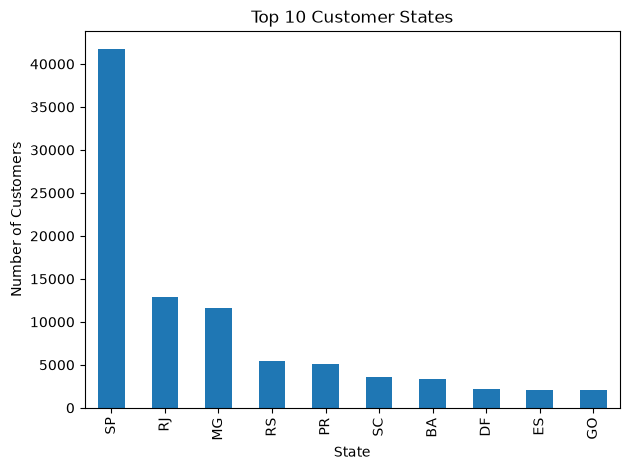

In [65]:
customers["customer_state"].value_counts().head (10).plot(kind="bar")
plt.title("Top 10 Customer States")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("../figures/customer.png")
plt.show()

In [66]:
#Initial Business Questions
#How many unique customers are present?
customers ["customer_unique_id"].nunique()

96096

In [67]:

#How many orders are present?
orders ["order_id"].nunique()

99441

In [68]:

#What are the most common order statuses?
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [69]:
#What are the most common payment methods?
payments ["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [70]:

#What is the average review score?
reviews["review_score"].mean()

np.float64(4.08642062404257)

In [71]:
import os
import pandas as pd

data_path = r"..\data\raw"
data_dict = []
for file in os.listdir(data_path):
    if file.endswith(".csv"):
        file_path = os.path.join(data_path, file)
        try:
            df = pd.read_csv(file_path, nrows=5)
            for col in df.columns:
                entry = {
                    "File_Name": file,
                    "Column_Name": col,
                    "Data_Type": str(df[col].dtype),
                    "Sample_Value": df[col].iloc[0] if not df[col].empty else None
                }
                data_dict.append(entry)
        except Exception as e:
            print(f"Error reading {file}: {e}")

data_dictionary = pd.DataFrame(data_dict)
output_path = os.path.join(data_path, "Olist_Data_Dictionary.csv")
data_dictionary.to_csv(output_path, index=False)

print(f"Data dictionary created and saved at: {output_path}")

Data dictionary created and saved at: ..\data\raw\Olist_Data_Dictionary.csv
